In [3]:
from IPython import get_ipython

ipython = get_ipython()

# enable autoreload for interactive sessions
if ipython is not None:
    ipython.run_line_magic("load_ext", "autoreload")
    ipython.run_line_magic("autoreload", "2")
import os 

import numpy as np
from astropy.io import fits
from astropy.cosmology import Planck18
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import scale as mscale
import seaborn as sns
from tqdm import tqdm
import healpy as hp
import pymaster as nmt
import camb
import skymapper as skm

from sp_validation.utils_cosmo_val import SquareRootScale
from sp_validation.cosmo_val import CosmologyValidation
from sp_validation.cosmology import get_theo_c_ell, get_cosmo
from sp_validation.rho_tau import get_params_rho_tau

import utils

mscale.register_scale(SquareRootScale)

plt.style.use(
    '/home/guerrini/matplotlib_config/paper.mplstyle'
)
plt.rcParams['text.usetex'] = True

sns.set_palette("Dark2")

if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Investigation of NaMaster covariance

In [4]:
#Utils paths
path_cat_gal = '/n17data/UNIONS/WL/v1.4.x/v1.4.6.3/unions_shapepipe_cut_struc_2024_v1.4.6.3.fits'
path_redshift_distr = '/n17data/sguerrini/UNIONS/WL/nz/v1.4.6.3/nz_SP_v1.4.6.3_B.txt'
root_glass = "/n09data/guerrini/glass_mock_v1.4.6.3_v2/results/"
path_cl_measurement = '/home/guerrini/sp_validation/notebooks/cosmo_val/output/pseudo_cl_SP_v1.4.6.3_leak_corr_B.fits'
path_cat_des = '/n17data/mkilbing/astro/data/DES/DES_Y3_cut.fits'
path_cat_glass = '/n09data/guerrini/glass_mock_v1.4.6.3_v2/results/unions_glass_sim_00001_4096.fits'

# Load onecovariance estimate
pseudo_cl_cov = fits.open(
    '/home/guerrini/sp_validation/notebooks/cosmo_val/output/pseudo_cl_cov_g_ng_OneCovariance_SP_v1.4.6.3_leak_corr_B.fits'
)
# Load namaster estimate from cosmo_val
pseudo_cl_cov_namaster = fits.open(
    '/home/guerrini/sp_validation/notebooks/cosmo_val/output/pseudo_cl_cov_SP_v1.4.6.3_leak_corr_B.fits'
)

nside = 1024
lmin = 8
lmax = 2048
ell_coupled = np.arange(1, lmax+1)
num_bins = 32
b = utils.get_binning(lmin, lmax, num_bins)
ell_eff = b.get_effective_ells()

## 1. Comparing coupled and uncoupled $C_\ell$ with catalog- and map-based methods

In [3]:
ra, dec, e1, e2, w = utils.load_cat(path_cat_gal)

e1_rot, e2_rot = utils.apply_random_rotations(e1, e2)
f_cat, wsp_cat = utils.get_field_and_workspace_cat(
    ra, dec, e1, e2, lmax - 1, b, w
)

In [4]:
cl_noise_coupled = nmt.compute_coupled_cell(f_cat, f_cat)
cl_noise = wsp_cat.decouple_cell(cl_noise_coupled)

In [5]:
coupling_cat = wsp_cat.get_coupling_matrix()
coupling_cat_re = np.reshape(coupling_cat, (lmax, 4, lmax, 4), order='F')

<Figure size 640x480 with 0 Axes>

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


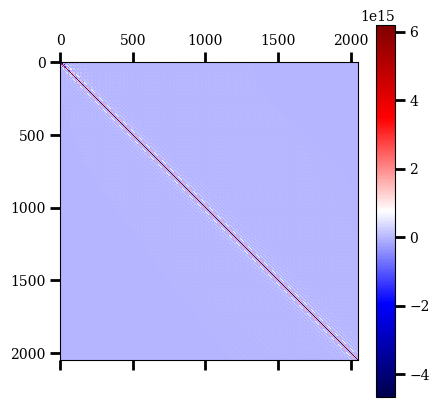

In [6]:
plt.figure()

plt.matshow(coupling_cat_re[:, 0, :, 0], cmap='seismic')
plt.colorbar()

plt.show()

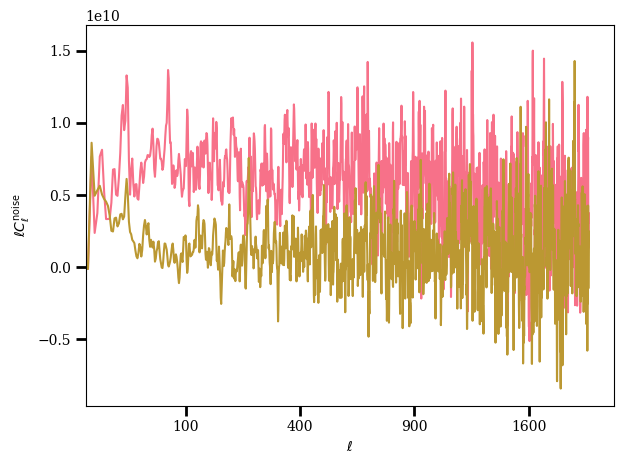

In [7]:
plt.figure()

plt.plot(
    ell_coupled,
    ell_coupled*cl_noise_coupled[0],
    label='E-modes',
)

plt.plot(
    ell_coupled,
    ell_coupled*cl_noise_coupled[3],
    label='B-modes',
)

plt.xscale('squareroot')
xticks = [100, 400, 900, 1600]
plt.xticks(xticks, xticks)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell C_\ell^{\mathrm{noise}}$")

plt.show()

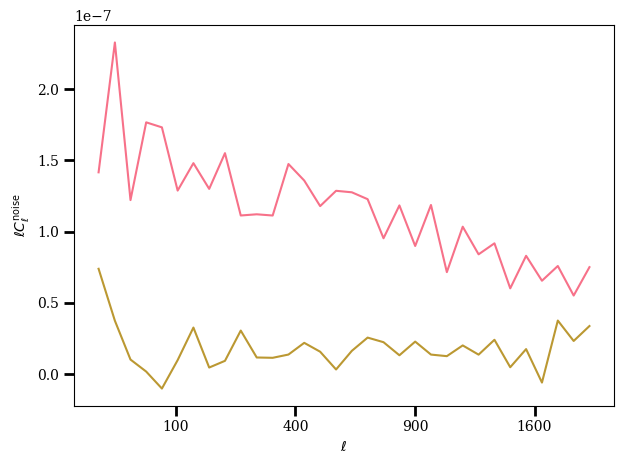

In [8]:
plt.figure()

plt.plot(
    ell_eff,
    ell_eff*cl_noise[0],
    label='E-modes',
)

plt.plot(
    ell_eff,
    ell_eff*cl_noise[3],
    label='B-modes',
)

plt.xscale('squareroot')
xticks = [100, 400, 900, 1600]
plt.xticks(xticks, xticks)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell C_\ell^{\mathrm{noise}}$")

plt.show()

In [9]:
cov_cat, cl_cat = utils.get_covariance_from_glass(
    root=root_glass,
    n_sim=350,
    num_bins=num_bins,
    lmax=lmax,
    type='cat'
)

cov_cat_coupled, cl_cat_coupled = utils.get_covariance_from_glass(
    root=root_glass,
    n_sim=350,
    num_bins=num_bins,
    lmax=lmax,
    type='cat_coupled'
)

cov_map, cl_map = utils.get_covariance_from_glass(
    root=root_glass,
    n_sim=350,
    num_bins=num_bins,
    lmax=lmax,
    type='map'
)

cov_map_coupled, cl_map_coupled = utils.get_covariance_from_glass(
    root=root_glass,
    n_sim=350,
    num_bins=num_bins,
    lmax=lmax,
    type='map_coupled'
)

  0%|          | 0/350 [00:00<?, ?it/s]

100%|██████████| 350/350 [00:00<00:00, 1060.31it/s]


In [48]:
plt.figure()

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_cat)),
    label='Catalog-based'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_map)),
    label='Map-based'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(pseudo_cl_cov["COVAR_GAUSSIAN"].data)),
    label='OneCovariance'
    color='black',
    linstyle='--'
)

plt.xscale('squareroot')
xticks = [100, 400, 900, 1600]
plt.xticks(xticks, xticks)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\sigma(C_\ell)$")
plt.yscale('log')
plt.legend()

plt.savefig("./plots/errorbar_glass_mock_cat_vs_map.png", dpi=300)
plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (4210442297.py, line 18)

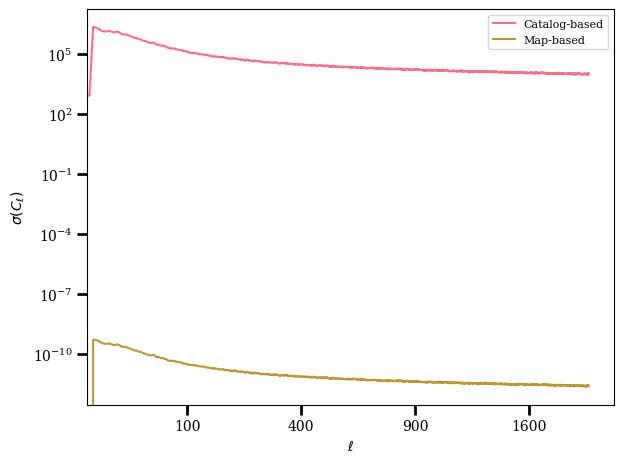

In [11]:
plt.figure()

plt.plot(
    ell_coupled,
    np.sqrt(np.diag(cov_cat_coupled)),
    label='Catalog-based'
)

plt.plot(
    ell_coupled,
    np.sqrt(np.diag(cov_map_coupled)),
    label='Map-based'
)

plt.xscale('squareroot')
xticks = [100, 400, 900, 1600]
plt.xticks(xticks, xticks)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\sigma(C_\ell)$")
plt.yscale('log')
plt.legend()

plt.savefig("./plots/errorbar_glass_mock_cat_vs_map_coupled.png", dpi=300)

plt.show()

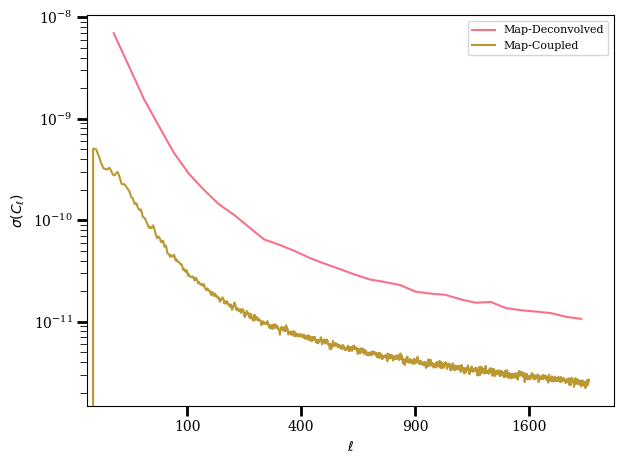

In [12]:
plt.figure()

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_map)),
    label='Map-Deconvolved'
)

plt.plot(
    ell_coupled,
    np.sqrt(np.diag(cov_map_coupled)),
    label='Map-Coupled'
)

plt.xscale('squareroot')
xticks = [100, 400, 900, 1600]
plt.xticks(xticks, xticks)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\sigma(C_\ell)$")
plt.yscale('log')

plt.legend()

plt.savefig("./plots/errorbar_glass_mock_map_deconvolved_vs_coupled.png", dpi=300)

plt.show()

### Computation of the noise bias

In [13]:
#Get samples from the noise bias
if os.path.exists("./data/cl_noise_bias.npy"):
    cl_noise_bias = np.load("./data/cl_noise_bias.npy")
else:
    cl_noise_bias = np.array([]).reshape((0, 4, num_bins))

    n_gal, unique_pix, idx, idx_rep = utils.get_n_gal_map(nside, ra, dec, w)
    mask = n_gal > 0


    for i in tqdm(range(50)):
        noise_map = utils.get_gaussian_real(
            nside=nside,
            mask=mask,
            n_gal=n_gal,
            unique_pix=unique_pix,
            idx_rep=idx_rep,
            e1=e1,
            e2=e2,
            w=w
        )

        if i == 0:
            _, wsp = utils.get_field_and_workspace_map(
                mask,
                lmax - 1,
                b
            )

        cl_noise, _, _, _ = utils.get_sample(noise_map, mask, lmax - 1, b, wsp=wsp)
        cl_noise_bias = np.vstack((cl_noise_bias, cl_noise[np.newaxis, :, :]))
        np.save("./data/cl_noise_bias.npy", cl_noise_bias)

In [14]:
noise_bias = np.mean(cl_noise_bias, axis=0)

In [15]:
#Theoretical estimate
ra, dec, e1, e2, w = utils.load_cat(path_cat_gal)

n_gal, unique_pix, idx, idx_rep = utils.get_n_gal_map(nside, ra, dec, w)
mask = n_gal > 0

variance_map = np.zeros(hp.nside2npix(nside))
variance_map[unique_pix] = np.bincount(idx_rep, weights=(e1**2 + e2**2)/2 * w**2)

noise_bias_th = hp.nside2pixarea(nside) * np.mean(variance_map)
print(noise_bias_th)

_, wsp = utils.get_field_and_workspace_map(
    mask, lmax - 1, b
)

cl_in = np.zeros((4, lmax))
cl_in[0, :] = noise_bias_th
cl_in[3, :] = noise_bias_th
noise_bias_decoupled = wsp.decouple_cell(cl_in)

6.303112952663985e-05


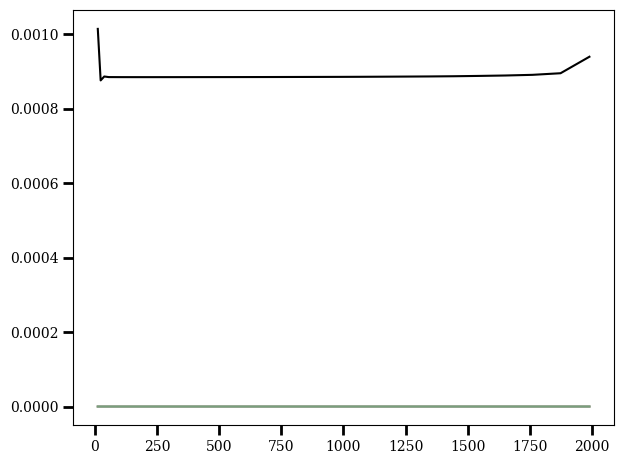

In [16]:
plt.figure()

for i in range(10):
    plt.plot(ell_eff, cl_noise_bias[i, 0], alpha=0.3)

plt.plot(ell_eff, noise_bias_decoupled[0], color='black', label="Theory estimation")
plt.show()

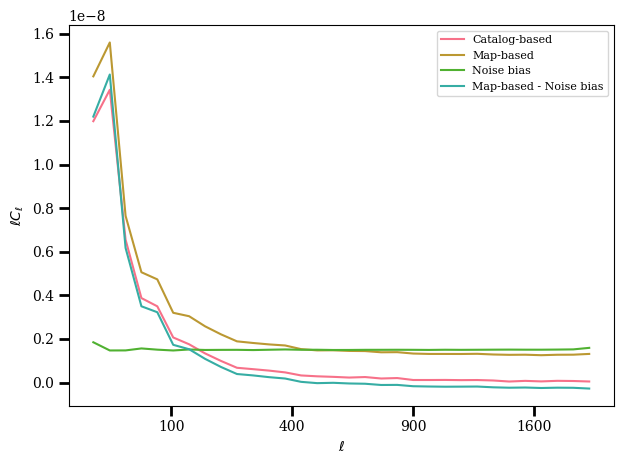

In [17]:
#Plot catalog vs map
plt.figure()

plt.plot(
    ell_eff,
    cl_cat[0],
    label='Catalog-based',
)

plt.plot(
    ell_eff,
    cl_map[0],
    label='Map-based',
)

plt.plot(
    ell_eff,
    noise_bias[0],
    label='Noise bias',
)

plt.plot(
    ell_eff,
    cl_map[0] - noise_bias[0],
    label='Map-based - Noise bias',
)

plt.legend()
plt.xscale('squareroot')
xticks = [100, 400, 900, 1600]
plt.xticks(xticks, xticks)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell C_\ell$")

plt.show()

### Estimating the noise bias on DES

In [18]:
#Theoretical estimate
ra, dec, e1, e2, w = utils.load_cat_des(path_cat_des)

n_gal_des, unique_pix_des, idx_des, idx_rep_des = utils.get_n_gal_map(nside, ra, dec, w)
mask_des = n_gal_des > 0

variance_map = np.zeros(hp.nside2npix(nside))
_w = w * float(len(w)) / np.sum(w)
variance_map[unique_pix_des] = np.bincount(idx_rep_des, weights=(e1**2 + e2**2)/2 * _w**2)

noise_bias_th = hp.nside2pixarea(nside) * np.mean(variance_map)
print(noise_bias_th)

_, wsp = utils.get_field_and_workspace_map(
    mask_des, lmax - 1, b
)

cl_in = np.zeros((4, lmax))
cl_in[0, :] = noise_bias_th
cl_in[3, :] = noise_bias_th
noise_bias_decoupled = wsp.decouple_cell(cl_in)

6.916986398858452e-07


## 2. Different ways of feeding the covariance estimator

In [19]:
# Fiducial theory
ra, dec, e1, e2, w = utils.load_cat(path_cat_gal)
z, dndz = utils.load_redshift_distr(path_redshift_distr)

fiducial = utils.get_theory(lmax, z, dndz)

#Get field, wsp and cw
n_gal, unique_pix, idx, idx_rep = utils.get_n_gal_map(nside, ra, dec, w)
mask = n_gal > 0
f, wsp = utils.get_field_and_workspace_map(
    mask, lmax - 1, b
)
cw = nmt.NmtCovarianceWorkspace.from_fields(f, f, f, f)

In [20]:
#Get the noise bias
noise_bias_ = np.mean(
    np.load("./data/cl_noise_bias.npy"),
    axis=0
)

noise_bias = b.unbin_cell(noise_bias_)
lowest_ell = b.get_ell_list(0)[0]
for i in range(4):
    noise_bias[i, :lowest_ell] = noise_bias[i, lowest_ell]

In [21]:
fiducial_noise = np.array([
    fiducial,
    0.*fiducial,
    0.*fiducial,
    0.*fiducial
]) + noise_bias

cov_theo = utils.get_covariance(
    fiducial_noise,
    cw,
    wsp,
    num_bins
).reshape((num_bins, 4, num_bins, 4))

In [22]:
#Apply coupling matrix to the fiducial theory
ra, dec, e1, e2, w = utils.load_cat(path_cat_gal)

n_gal, unique_pix, idx, idx_rep = utils.get_n_gal_map(nside, ra, dec, w)
mask = n_gal > 0

coupling = wsp.get_coupling_matrix()
coupling_re = np.reshape(coupling, (4, lmax, 4, lmax), order='F')
coupled_fiducial = np.tensordot(coupling_re, fiducial_noise) / np.mean(mask**2)


cov_theo_coupled = utils.get_covariance(
    coupled_fiducial,
    cw,
    wsp,
    num_bins
).reshape((num_bins, 4, num_bins, 4))

In [23]:


shear_map_e1 = np.zeros(hp.nside2npix(nside))
shear_map_e2 = np.zeros(hp.nside2npix(nside))

shear_map_e1[unique_pix] = np.bincount(idx_rep, weights=e1 * w)
shear_map_e2[unique_pix] = np.bincount(idx_rep, weights=e2 * w)
shear_map_e1[mask] /= n_gal[unique_pix]
shear_map_e2[mask] /= n_gal[unique_pix]

f = nmt.NmtField(mask, [shear_map_e1, -shear_map_e2], lmax=lmax - 1)

cl_data = nmt.compute_coupled_cell(f, f)

wsp = nmt.NmtWorkspace.from_fields(f, f, b)

cl_data_decoupled = wsp.decouple_cell(cl_data)

cl_data_decoupled = b.unbin_cell(cl_data_decoupled)
lowest_ell = b.get_ell_list(0)[0]
for i in range(4):
    cl_data_decoupled[i, :lowest_ell] = cl_data_decoupled[i, lowest_ell]


cov_data = utils.get_covariance(
    cl_data / np.mean(mask**2),
    cw,
    wsp,
    num_bins
).reshape((num_bins, 4, num_bins, 4))


cov_data_decoupled = utils.get_covariance(
    cl_data_decoupled,
    cw,
    wsp,
    num_bins
).reshape((num_bins, 4, num_bins, 4))

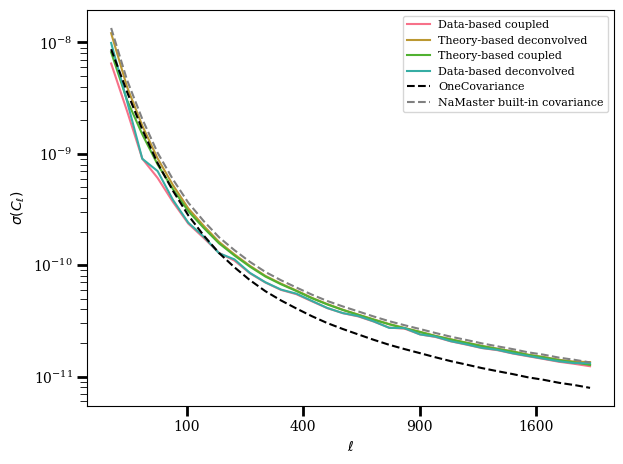

In [24]:
plt.figure()

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_data[:, 0, :, 0])),
    label='Data-based coupled'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_theo[:, 0, :, 0])),
    label='Theory-based deconvolved'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_theo_coupled[:, 0, :, 0])),
    label='Theory-based coupled'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_data_decoupled[:, 0, :, 0])),
    label='Data-based deconvolved'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(pseudo_cl_cov["COVAR_GAUSSIAN"].data)),
    color='black',
    linestyle='--',
    label='OneCovariance'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(pseudo_cl_cov_namaster["COVAR_EE_EE"].data)),
    color='gray',
    label='NaMaster built-in covariance',
    linestyle='--'
)

plt.xscale('squareroot')
xticks = [100, 400, 900, 1600]
plt.xticks(xticks, xticks)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\sigma(C_\ell)$")
plt.yscale('log')

plt.legend()

plt.savefig("./plots/errorbar_feeding_namaster_covariance.png", dpi=300)

plt.show()

## 3. Different modeling of the noise bias

We use a GLASS mock realisation where there should not be any spatial variation to estimate the noise bias.

In [25]:
ra, dec, e1, e2, w = utils.load_cat(path_cat_glass, w_col=None)
#Get samples from the noise bias
if os.path.exists("./data/cl_noise_bias_glass.npy"):
    cl_noise_bias = np.load("./data/cl_noise_bias_glass.npy")
else:
    cl_noise_bias = np.array([]).reshape((0, 4, num_bins))

    n_gal, unique_pix, idx, idx_rep = utils.get_n_gal_map(nside, ra, dec, w)
    mask = n_gal > 0


    for i in tqdm(range(50)):
        noise_map = utils.get_gaussian_real(
            nside=nside,
            mask=mask,
            n_gal=n_gal,
            unique_pix=unique_pix,
            idx_rep=idx_rep,
            e1=e1,
            e2=e2,
            w=w
        )

        if i == 0:
            _, wsp = utils.get_field_and_workspace_map(
                mask,
                lmax - 1,
                b
            )

        cl_noise, _, _, _ = utils.get_sample(noise_map, mask, lmax - 1, b, wsp=wsp)
        cl_noise_bias = np.vstack((cl_noise_bias, cl_noise[np.newaxis, :, :]))
        np.save("./data/cl_noise_bias_glass.npy", cl_noise_bias)

In [26]:
#Run the comparison
# Fiducial theory
ra, dec, e1, e2, w = utils.load_cat(path_cat_gal)
z, dndz = utils.load_redshift_distr(path_redshift_distr)

fiducial = utils.get_theory(lmax, z, dndz)

#Get field, wsp and cw
n_gal, unique_pix, idx, idx_rep = utils.get_n_gal_map(nside, ra, dec, w)
mask = n_gal > 0
f, wsp = utils.get_field_and_workspace_map(
    mask, lmax - 1, b
)
cw = nmt.NmtCovarianceWorkspace.from_fields(f, f, f, f)

In [27]:
# Using noise bias from UNIONS catalog
noise_bias_ = np.mean(
    np.load("./data/cl_noise_bias.npy"),
    axis=0
)

noise_bias = b.unbin_cell(noise_bias_)
lowest_ell = b.get_ell_list(0)[0]
for i in range(4):
    noise_bias[i, :lowest_ell] = noise_bias[i, lowest_ell]

fiducial_noise = np.array([
    fiducial,
    0.*fiducial,
    0.*fiducial,
    0.*fiducial
]) + noise_bias

# Using noise bias from GLASS mock
noise_bias_ = np.mean(
    np.load("./data/cl_noise_bias_glass.npy"),
    axis=0
)

noise_bias_glass = b.unbin_cell(noise_bias_)
lowest_ell = b.get_ell_list(0)[0]
for i in range(4):
    noise_bias_glass[i, :lowest_ell] = noise_bias_glass[i, lowest_ell]

fiducial_noise_glass = np.array([
    fiducial,
    0.*fiducial,
    0.*fiducial,
    0.*fiducial
]) + noise_bias_glass

In [28]:
# Estimate the noise bias from theory

sigma_e = 0.3796 / np.sqrt(2)
n_eff = 6.128 #arcmin^-2
n_eff = n_eff * 60**2  # convert to deg-2
n_eff = n_eff * (180/np.pi)**2  # convert to sr^-1

n_l = sigma_e**2 / (2 * n_eff)
print("Noise bias: ", n_l)

noise_bias_theo = np.zeros((4, lmax))
noise_bias_theo[0, :] = n_l
noise_bias_theo[3, :] = n_l

noise_bias_theo = wsp.decouple_cell(noise_bias_theo)
noise_bias_theo = b.unbin_cell(noise_bias_theo)
lowest_ell = b.get_ell_list(0)[0]
for i in range(4):
    noise_bias_theo[i, :lowest_ell] = noise_bias_theo[i, lowest_ell]


fiducial_noise_theo = np.array([
    fiducial,
    0.*fiducial,
    0.*fiducial,
    0.*fiducial
]) + noise_bias_theo

Noise bias:  4.974230361135217e-10


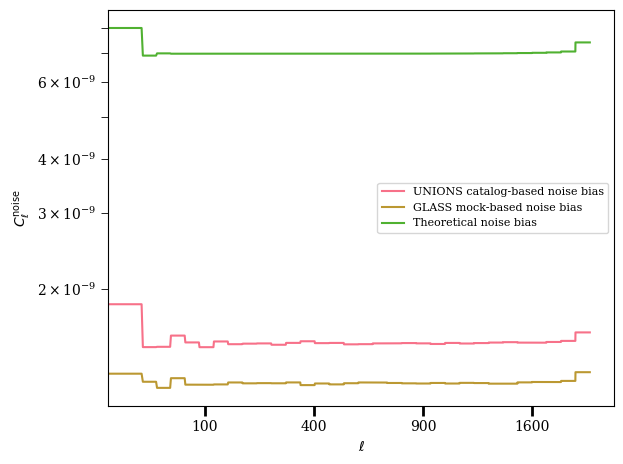

In [29]:
#Compare the noise biases
plt.figure()

plt.plot(ell_coupled, noise_bias[0], label='UNIONS catalog-based noise bias')
plt.plot(ell_coupled, noise_bias_glass[0], label='GLASS mock-based noise bias')
plt.plot(ell_coupled, noise_bias_theo[0], label='Theoretical noise bias')

plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell^{\mathrm{noise}}$")
plt.xscale('squareroot')
plt.yscale('log')
xticks = [100, 400, 900, 1600]
plt.xticks(xticks, xticks)
plt.legend()

plt.savefig("./plots/noise_bias_comparison_unions_vs_glass.png", dpi=300)
plt.show()

In [30]:
# Compute the covariance
cov_unions = utils.get_covariance(
    fiducial_noise,
    cw,
    wsp,
    num_bins
).reshape((num_bins, 4, num_bins, 4))

cov_glass = utils.get_covariance(
    fiducial_noise_glass,
    cw,
    wsp,
    num_bins
).reshape((num_bins, 4, num_bins, 4))

cov_theo = utils.get_covariance(
    fiducial_noise_theo,
    cw,
    wsp,
    num_bins
).reshape((num_bins, 4, num_bins, 4))

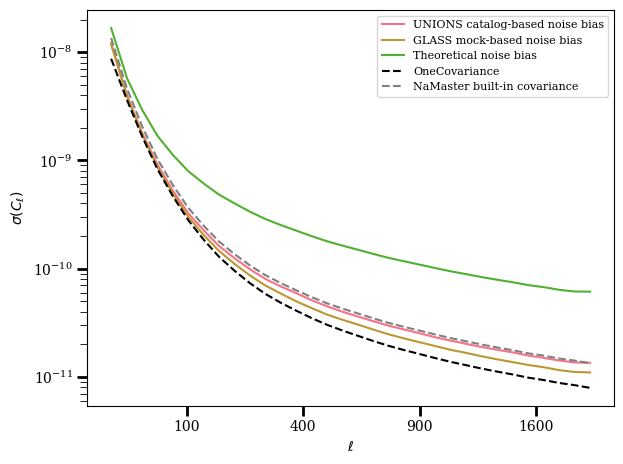

In [31]:
plt.figure()

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_unions[:, 0, :, 0])),
    label='UNIONS catalog-based noise bias'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_glass[:, 0, :, 0])),
    label='GLASS mock-based noise bias'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_theo[:, 0, :, 0])),
    label='Theoretical noise bias'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(pseudo_cl_cov["COVAR_GAUSSIAN"].data)),
    color='black',
    linestyle='--',
    label='OneCovariance'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(pseudo_cl_cov_namaster["COVAR_EE_EE"].data)),
    color='gray',
    label='NaMaster built-in covariance',
    linestyle='--'
)

plt.xscale('squareroot')
xticks = [100, 400, 900, 1600]
plt.xticks(xticks, xticks)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\sigma(C_\ell)$")
plt.yscale('log')

plt.legend()

plt.savefig("./plots/errorbar_comparison_noise_bias.png", dpi=300)

plt.show()

## 4. Theoretical estimate of the noise bias

In [5]:
ra, dec, e1, e2, w = utils.load_cat(path_cat_gal)

n_gal, unique_pix, idx, idx_rep = utils.get_n_gal_map(nside, ra, dec, w)
mask = n_gal > 0
variance_map = np.zeros(hp.nside2npix(nside))
variance_map[unique_pix] = np.bincount(idx_rep, weights=(e1**2 + e2**2)/2 * w**2)

noise_bias_th = hp.nside2pixarea(nside) * np.mean(variance_map)
print(noise_bias_th)


6.15747237395912e-05


In [6]:
variance_map_plot = variance_map.copy()
variance_map_plot[~mask] = np.nan


In [7]:
# 1) construct a projection, here Albers
# lon_0, lat_0: longitude/latitude that map onto 0/0
# lat_1, lat_2: reference latitudes for conic projection
lon_0, lat_0, lat_1, lat_2 = 0, 90, 30, 90
proj = skm.Albers(lon_0, lat_0, lat_1, lat_2)


coucou
coucou


/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/skymapper/projection.py:464: RuntimeWarning: invalid value encountered in arcsin
  lat = np.arcsin((self.C - (rho * self.n)**2)/(2*self.n)) / DEG2RAD


coucou
vmin, vmax:  0.0 16.0
Coucou


/tmp/ipykernel_1295885/2372986977.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


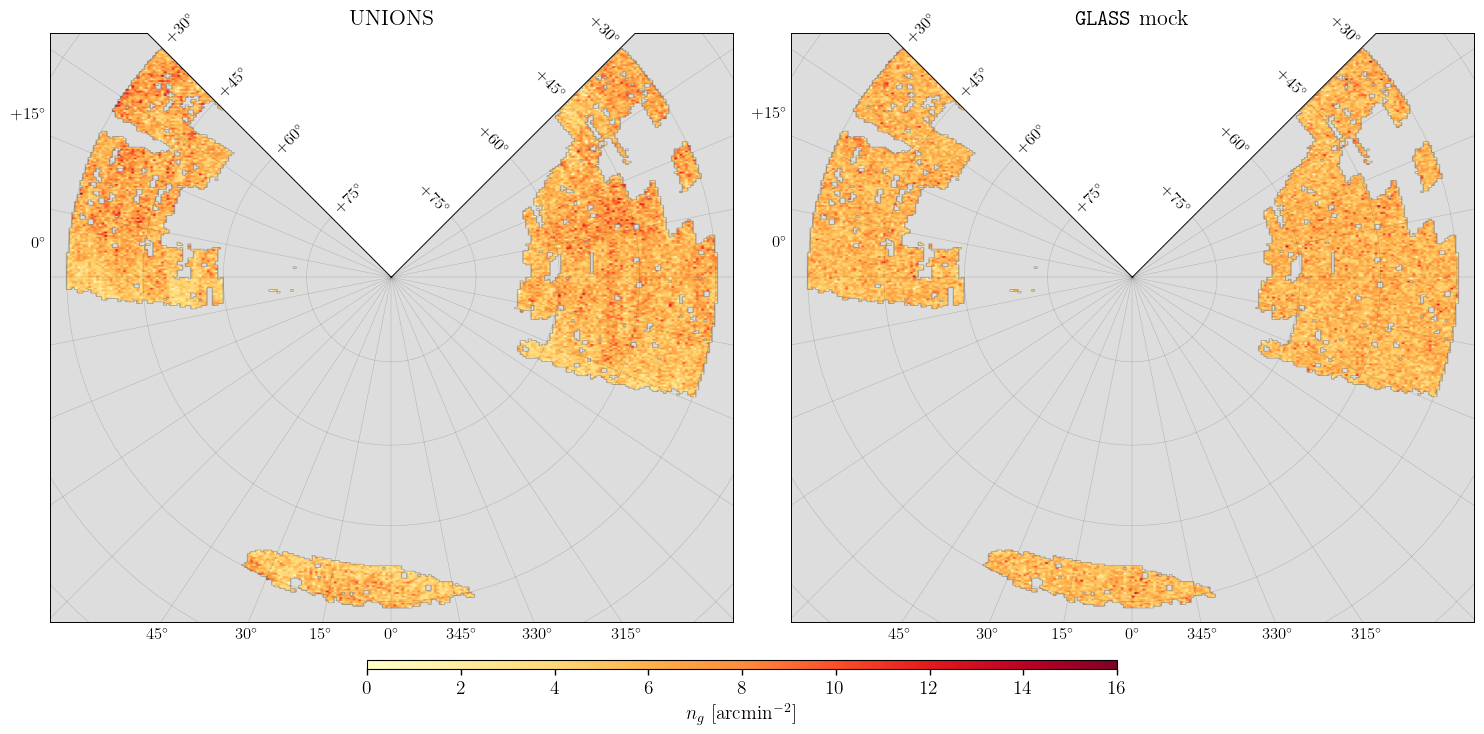

In [8]:
ra, dec, e1, e2, w = utils.load_cat(path_cat_gal)
ra_glass, dec_glass, e1_glass, e2_glass, w_glass = utils.load_cat(path_cat_glass, w_col=None)

print("coucou")

fig, axs = plt.subplots(1, 2, figsize=(15, 9))

# Plot UNIONS density map

# 2) construct map: will hold figure and projection
# the outline of the sphere can be styled with kwargs for matplotlib Polygon
map = skm.Map(proj, ax=axs[0])
map_glass = skm.Map(proj, ax=axs[1])

# 3) add graticules, separated by 15 deg
# the lines can be styled with kwargs for matplotlib Line2D
# additional arguments for formatting the graticule labels
sep = 15
map.grid(sep=sep)
map_glass.grid(sep=sep)

print("coucou")

# 4) add data to the map, e.g.
# make density plot
nside = 1024
mappable = map.density(ra, dec, nside=nside)
mappable_glass = map_glass.density(ra_glass, dec_glass, nside=nside)

print("coucou")

vmin = min(mappable.get_clim()[0], mappable_glass.get_clim()[0])
vmax = max(mappable.get_clim()[1], mappable_glass.get_clim()[1])

vmax = np.ceil(vmax)
if vmax % 2 != 0:
    vmax += 1

print("vmin, vmax: ", vmin, vmax)
mappable.set_clim(vmin, vmax)
mappable_glass.set_clim(vmin, vmax)

print("Coucou")
map.focus(ra, dec)
map_glass.focus(ra_glass, dec_glass)

axs[0].set_title("UNIONS", fontsize=16)
axs[1].set_title(r"\texttt{GLASS} mock", fontsize=16)

cbar_ax = fig.add_axes([0.25, 0.12, 0.5, 0.01])
cbar = fig.colorbar(
    mappable,
    cax=cbar_ax,
    orientation='horizontal',
    fraction=0.05,
    pad=0.1,
)
cbar.set_label("$n_g$ [arcmin$^{-2}$]", fontsize=14)
cbar.ax.tick_params(width=1, length=4, labelsize=14)

plt.tight_layout()
plt.savefig("./plots/number_density_map_unions_vs_glass.png", dpi=300)
#Save to pdf format as well
plt.savefig("./plots/number_density_map_unions_vs_glass.pdf")
plt.show()

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/skymapper/projection.py:464: RuntimeWarning: invalid value encountered in arcsin
  lat = np.arcsin((self.C - (rho * self.n)**2)/(2*self.n)) / DEG2RAD


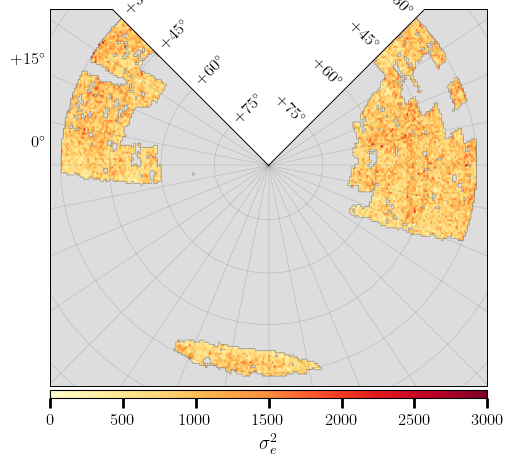

In [9]:
# 2) construct map: will hold figure and projection
# the outline of the sphere can be styled with kwargs for matplotlib Polygon
map = skm.Map(proj)

# 3) add graticules, separated by 15 deg
# the lines can be styled with kwargs for matplotlib Line2D
# additional arguments for formatting the graticule labels
sep = 15
map.grid(sep=sep)

# 4) add data to the map, e.g.
# make density plot
nside = 1024
mappable = map.healpix(np.ma.masked_invalid(variance_map_plot), vmin=0, vmax=3000)
cb = map.colorbar(mappable, cb_label="$\sigma_e^2$", loc="bottom")

map.focus(ra, dec)

In [37]:
nside_map = 4096

shear_map_e1 = np.zeros(hp.nside2npix(nside_map))
shear_map_e2 = np.zeros(hp.nside2npix(nside_map))

n_gal_map, unique_pix_map, idx_map, idx_rep_map = utils.get_n_gal_map(nside_map, ra, dec, w)
mask_map = n_gal_map > 0

shear_map_e1[unique_pix_map] = np.bincount(idx_rep_map, weights=e1 * w)
shear_map_e2[unique_pix_map] = np.bincount(idx_rep_map, weights=e2 * w)
shear_map_e1[mask_map] /= n_gal_map[unique_pix_map]
shear_map_e2[mask_map] /= n_gal_map[unique_pix_map]

shear_map_e1[~mask_map] = np.nan
shear_map_e2[~mask_map] = np.nan

/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/skymapper/projection.py:464: RuntimeWarning: invalid value encountered in arcsin
  lat = np.arcsin((self.C - (rho * self.n)**2)/(2*self.n)) / DEG2RAD


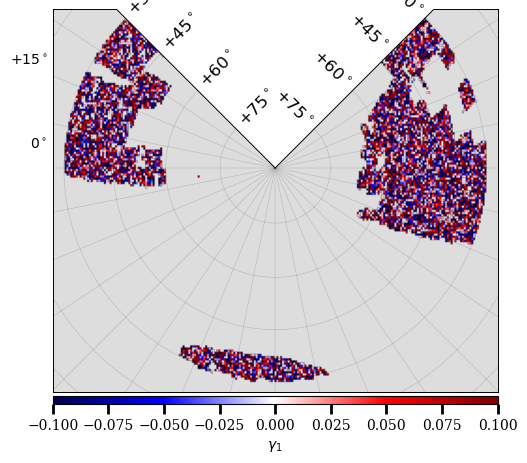

In [38]:
# 2) construct map: will hold figure and projection
# the outline of the sphere can be styled with kwargs for matplotlib Polygon
map = skm.Map(proj)

# 3) add graticules, separated by 15 deg
# the lines can be styled with kwargs for matplotlib Line2D
# additional arguments for formatting the graticule labels
sep = 15
map.grid(sep=sep)

# 4) add data to the map, e.g.
# make density plot
nside = 1024
mappable = map.healpix(shear_map_e1, cmap='seismic')
cb = map.colorbar(mappable, cb_label="$\gamma_1$", loc="bottom")

map.focus(ra, dec)

In [39]:
shear_map_e1[~mask_map] = 0.0
smoothed_shear_map_e1 = hp.smoothing(
    shear_map_e1,
    fwhm=np.radians(10/60),
    verbose=False
)
smoothed_mask = hp.smoothing(
    mask_map.astype(float),
    fwhm=np.radians(10/60),
    verbose=False
)
smoothed_shear_map_e1 = np.where(smoothed_mask > 1e-6,
                                 smoothed_shear_map_e1 / smoothed_mask,
                                 np.nan)

/tmp/ipykernel_131611/1075022504.py:2: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  smoothed_shear_map_e1 = hp.smoothing(
/tmp/ipykernel_131611/1075022504.py:7: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  smoothed_mask = hp.smoothing(
/tmp/ipykernel_131611/1075022504.py:13: RuntimeWarning: divide by zero encountered in divide
  smoothed_shear_map_e1 / smoothed_mask,
/tmp/ipykernel_131611/1075022504.py:13: RuntimeWarning: invalid value encountered in divide
  smoothed_shear_map_e1 / smoothed_mask,


/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/skymapper/projection.py:464: RuntimeWarning: invalid value encountered in arcsin
  lat = np.arcsin((self.C - (rho * self.n)**2)/(2*self.n)) / DEG2RAD


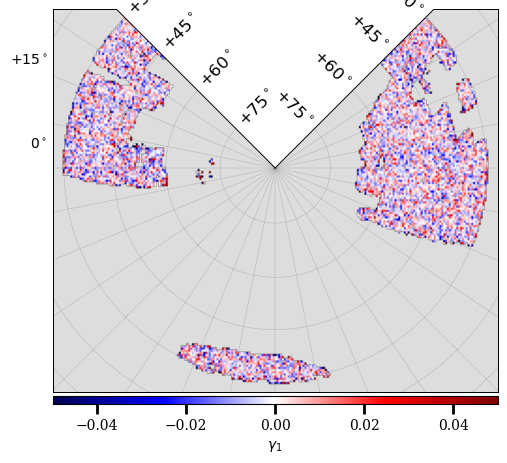

In [40]:
# 2) construct map: will hold figure and projection
# the outline of the sphere can be styled with kwargs for matplotlib Polygon
map = skm.Map(proj)

# 3) add graticules, separated by 15 deg
# the lines can be styled with kwargs for matplotlib Line2D
# additional arguments for formatting the graticule labels
sep = 15
map.grid(sep=sep)

# 4) add data to the map, e.g.
# make density plot
nside = 1024
mappable = map.healpix(smoothed_shear_map_e1, cmap='seismic', vmin=-0.05, vmax=0.05)
cb = map.colorbar(mappable, cb_label="$\gamma_1$", loc="bottom")

map.focus(ra, dec)

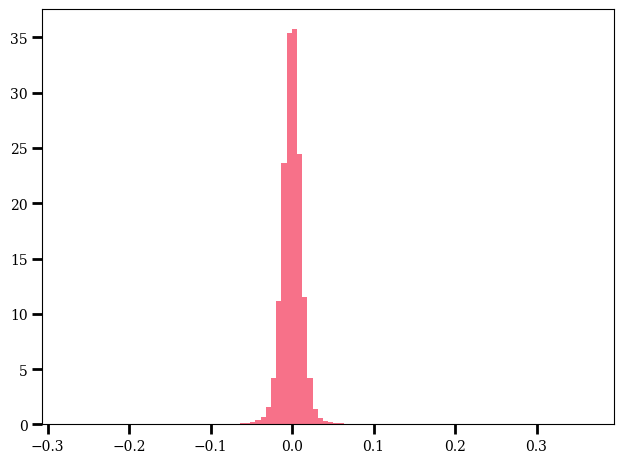

In [41]:
plt.figure()

plt.hist(smoothed_shear_map_e1[~np.isnan(smoothed_shear_map_e1)], bins=100, density=True)

plt.show()

## 5. Using the weighted number of galaxies as the mask

In [10]:
#Run the comparison
# Fiducial theory
ra, dec, e1, e2, w = utils.load_cat(path_cat_gal)
z, dndz = utils.load_redshift_distr(path_redshift_distr)

fiducial = utils.get_theory(lmax, z, dndz)

#Get field, wsp and cw
n_gal, unique_pix, idx, idx_rep = utils.get_n_gal_map(nside, ra, dec, w)
mask = n_gal > 0
f, wsp = utils.get_field_and_workspace_map(
    mask, lmax - 1, b
)
cw = nmt.NmtCovarianceWorkspace.from_fields(f, f, f, f)

# Using noise bias from UNIONS catalog
noise_bias_ = np.mean(
    np.load("./data/cl_noise_bias.npy"),
    axis=0
)

noise_bias = b.unbin_cell(noise_bias_)
lowest_ell = b.get_ell_list(0)[0]
for i in range(4):
    noise_bias[i, :lowest_ell] = noise_bias[i, lowest_ell]

fiducial_noise = np.array([
    fiducial,
    0.*fiducial,
    0.*fiducial,
    0.*fiducial
]) + noise_bias

cov_unions = utils.get_covariance(
    fiducial_noise,
    cw,
    wsp,
    num_bins
).reshape((num_bins, 4, num_bins, 4))

In [17]:
ra, dec, e1, e2, w = utils.load_cat(path_cat_gal)
#Get samples from the noise bias
if os.path.exists("./data/cl_noise_bias_n_gal.npy"):
    cl_noise_bias = np.load("./data/cl_noise_bias_n_gal.npy")
else:
    cl_noise_bias = np.array([]).reshape((0, 4, num_bins))

    n_gal, unique_pix, idx, idx_rep = utils.get_n_gal_map(nside, ra, dec, w)
    mask = n_gal > 0


    for i in tqdm(range(50)):
        noise_map = utils.get_gaussian_real(
            nside=nside,
            mask=mask,
            n_gal=n_gal,
            unique_pix=unique_pix,
            idx_rep=idx_rep,
            e1=e1,
            e2=e2,
            w=w
        )

        if i == 0:
            _, wsp = utils.get_field_and_workspace_map(
                n_gal,
                lmax - 1,
                b
            )

        cl_noise, _, _, _ = utils.get_sample(noise_map, n_gal, lmax - 1, b, wsp=wsp)
        cl_noise_bias = np.vstack((cl_noise_bias, cl_noise[np.newaxis, :, :]))
        np.save("./data/cl_noise_bias_n_gal.npy", cl_noise_bias)

100%|██████████| 50/50 [17:05<00:00, 20.51s/it]


In [18]:
#Run the comparison
# Fiducial theory
ra, dec, e1, e2, w = utils.load_cat(path_cat_gal)
z, dndz = utils.load_redshift_distr(path_redshift_distr)

fiducial = utils.get_theory(lmax, z, dndz)

#Get field, wsp and cw
n_gal, unique_pix, idx, idx_rep = utils.get_n_gal_map(nside, ra, dec, w)
mask = n_gal > 0
f, wsp = utils.get_field_and_workspace_map(
    n_gal, lmax - 1, b
)
cw = nmt.NmtCovarianceWorkspace.from_fields(f, f, f, f)

# Using noise bias from UNIONS catalog
noise_bias_ = np.mean(
    np.load("./data/cl_noise_bias_n_gal.npy"),
    axis=0
)

noise_bias = b.unbin_cell(noise_bias_)
lowest_ell = b.get_ell_list(0)[0]
for i in range(4):
    noise_bias[i, :lowest_ell] = noise_bias[i, lowest_ell]

fiducial_noise = np.array([
    fiducial,
    0.*fiducial,
    0.*fiducial,
    0.*fiducial
]) + noise_bias

cov_unions_n_gal = utils.get_covariance(
    fiducial_noise,
    cw,
    wsp,
    num_bins
).reshape((num_bins, 4, num_bins, 4))

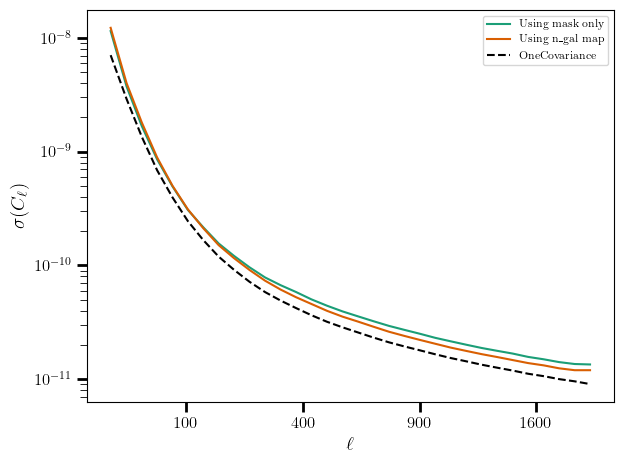

In [19]:
plt.figure()

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_unions[:, 0, :, 0])),
    label='Using mask only'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_unions_n_gal[:, 0, :, 0])),
    label='Using n_gal map'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(pseudo_cl_cov["COVAR_GAUSSIAN"].data)),
    color='black',
    linestyle='--',
    label='OneCovariance'
)

plt.xscale('squareroot')
xticks = [100, 400, 900, 1600]
plt.xticks(xticks, xticks)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\sigma(C_\ell)$")
plt.yscale('log')
plt.legend()

plt.savefig("./plots/errorbar_n_gal_map_vs_mask_only.png", dpi=300)
plt.show()

In [20]:
# Compute theorerical noise_bias for UNIONS catalog
ra, dec, e1, e2, w = utils.load_cat(path_cat_gal)

n_gal, unique_pix, idx, idx_rep = utils.get_n_gal_map(nside, ra, dec, w)
mask = n_gal > 0

variance_map = np.zeros(hp.nside2npix(nside))
variance_map[unique_pix] = np.bincount(
    idx_rep, weights=(e1**2 + e2**2)/2 * w**2
)

noise_bias_th = hp.nside2pixarea(nside) * np.mean(variance_map)
print(noise_bias_th)

noise_bias_theo = np.zeros((4, lmax))
noise_bias_theo[0, :] = noise_bias_th
noise_bias_theo[3, :] = noise_bias_th

_, wsp = utils.get_field_and_workspace_map(
    n_gal, lmax - 1, b
)

noise_bias_theo = wsp.decouple_cell(noise_bias_theo)
noise_bias_theo = b.unbin_cell(noise_bias_theo)
lowest_ell = b.get_ell_list(0)[0]
for i in range(4):
    noise_bias_theo[i, :lowest_ell] = noise_bias_theo[i, lowest_ell]

# Compute theorerical noise_bias for GLASS mock
ra, dec, e1, e2, w = utils.load_cat(path_cat_glass, w_col=None)

n_gal_glass, unique_pix_glass, idx_glass, idx_rep_glass = utils.get_n_gal_map(nside, ra, dec, w)
mask_glass = n_gal_glass > 0

variance_map_glass = np.zeros(hp.nside2npix(nside))

variance_map_glass[unique_pix_glass] = np.bincount(
    idx_rep_glass, weights=(e1**2 + e2**2)/2 * w**2
)
noise_bias_th_glass = hp.nside2pixarea(nside) * np.mean(variance_map_glass)
print(noise_bias_th_glass)

noise_bias_theo_glass = np.zeros((4, lmax))
noise_bias_theo_glass[0, :] = noise_bias_th_glass
noise_bias_theo_glass[3, :] = noise_bias_th_glass

_, wsp_glass = utils.get_field_and_workspace_map(
    n_gal_glass, lmax - 1, b
)

noise_bias_theo_glass = wsp_glass.decouple_cell(noise_bias_theo_glass)
noise_bias_theo_glass = b.unbin_cell(noise_bias_theo_glass)
lowest_ell = b.get_ell_list(0)[0]
for i in range(4):
    noise_bias_theo_glass[i, :lowest_ell] = noise_bias_theo_glass[i, lowest_ell]

# Using noise bias from UNIONS catalog
noise_bias_ = np.mean(
    np.load("./data/cl_noise_bias.npy"),
    axis=0
)

noise_bias = b.unbin_cell(noise_bias_)
lowest_ell = b.get_ell_list(0)[0]
for i in range(4):
    noise_bias[i, :lowest_ell] = noise_bias[i, lowest_ell]

# Using noise bias from GLASS mock
noise_bias_ = np.mean(
    np.load("./data/cl_noise_bias_glass.npy"),
    axis=0
)

noise_bias_glass = b.unbin_cell(noise_bias_)
lowest_ell = b.get_ell_list(0)[0]
for i in range(4):
    noise_bias_glass[i, :lowest_ell] = noise_bias_glass[i, lowest_ell]

6.15747237395912e-05
3.4501544839608087e-07


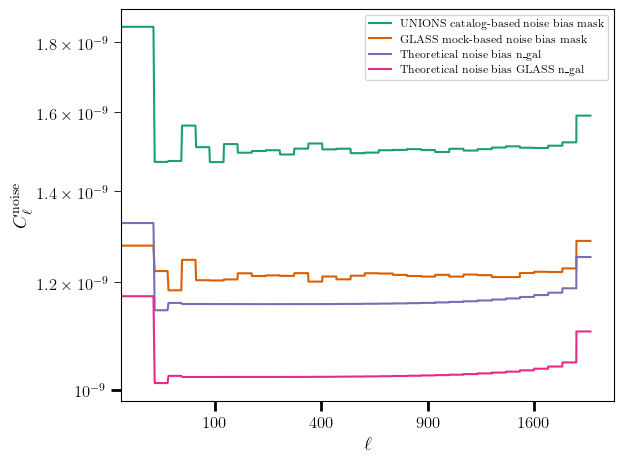

In [21]:
plt.figure()

plt.plot(
    ell_coupled, noise_bias[0], label='UNIONS catalog-based noise bias mask'
)
plt.plot(
    ell_coupled, noise_bias_glass[0], label='GLASS mock-based noise bias mask'
)
plt.plot(
    ell_coupled, noise_bias_theo[0], label='Theoretical noise bias n_gal'
)
plt.plot(
    ell_coupled, noise_bias_theo_glass[0], label='Theoretical noise bias GLASS n_gal'
)

plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell^{\mathrm{noise}}$")
plt.xscale('squareroot')
plt.yscale('log')
xticks = [100, 400, 900, 1600]
plt.xticks(xticks, xticks)
plt.legend()

plt.savefig("./plots/noise_bias_comparison_unions_vs_glass_vs_theory.png", dpi=300)
plt.show()

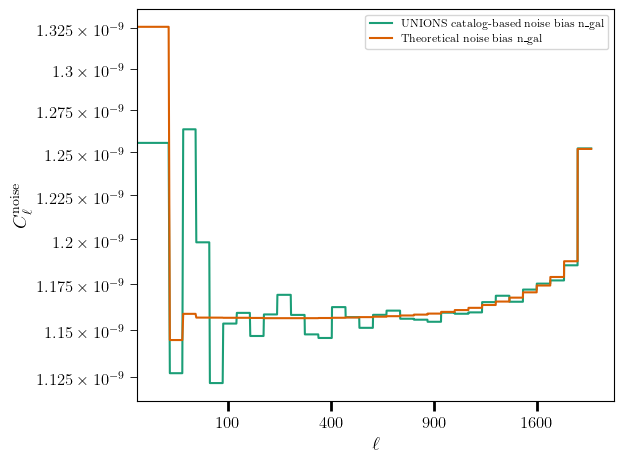

In [22]:
# Using noise bias from UNIONS catalog
noise_bias_ = np.mean(
    np.load("./data/cl_noise_bias_n_gal.npy"),
    axis=0
)

noise_bias = b.unbin_cell(noise_bias_)
lowest_ell = b.get_ell_list(0)[0]
for i in range(4):
    noise_bias[i, :lowest_ell] = noise_bias[i, lowest_ell]

plt.figure()

plt.plot(
    ell_coupled, noise_bias[0], label='UNIONS catalog-based noise bias n_gal'
)
plt.plot(
    ell_coupled, noise_bias_theo[0], label='Theoretical noise bias n_gal'
)

plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell^{\mathrm{noise}}$")
plt.xscale('squareroot')
plt.yscale('log')
xticks = [100, 400, 900, 1600]
plt.xticks(xticks, xticks)
plt.legend()

plt.savefig("./plots/noise_bias_comparison_unions_vs_glass_vs_theory_n_gal.png", dpi=300)
plt.show()

## 6. Final tests to match OneCovariance

Feed the covariance estimator with
- Analytical noise bias
- Couple and divide by the mean of the mask square (better agreement on large scales)
- Try to run with the GLASS mocks and see if it matches OneCovariance (if it does then this is a result from the inhomogeneity of the survey)

In [23]:
### Get covariances for UNIONS catalog
#Get field , wsp and cw
f, wsp = utils.get_field_and_workspace_map(
    n_gal, lmax - 1, b
)
cw = nmt.NmtCovarianceWorkspace.from_fields(f, f, f, f)

#Get the fiducial noise
fiducial_noise = np.array([ 
    fiducial,
    0.*fiducial,
    0.*fiducial,
    0.*fiducial
]) + noise_bias_theo

#Get the covariance
cov_unions_theo = utils.get_covariance(
    fiducial_noise,
    cw,
    wsp,
    num_bins
).reshape((num_bins, 4, num_bins, 4))

#Couple the fiducial
coupling = wsp.get_coupling_matrix()
coupling_re = np.reshape(coupling, (4, lmax, 4, lmax), order='F')
coupled_fiducial = np.tensordot(coupling_re, fiducial_noise) / np.mean(n_gal**2)

#Get the covariance
cov_unions_theo_coupled = utils.get_covariance(
    coupled_fiducial,
    cw,
    wsp,
    num_bins
).reshape((num_bins, 4, num_bins, 4))

### Get covariances for GLASS mock
#Get field , wsp and cw
f_glass, wsp_glass = utils.get_field_and_workspace_map(
    n_gal_glass, lmax - 1, b
)
cw_glass = nmt.NmtCovarianceWorkspace.from_fields(f_glass, f_glass, f_glass, f_glass)

#Get the fiducial noise
fiducial_noise_glass = np.array([
    fiducial,
    0.*fiducial,
    0.*fiducial,
    0.*fiducial
]) + noise_bias_theo_glass

#Get the covariance
cov_glass_theo = utils.get_covariance(
    fiducial_noise_glass,
    cw_glass,
    wsp_glass,
    num_bins
).reshape((num_bins, 4, num_bins, 4))

#Couple the fiducial
coupling_glass = wsp_glass.get_coupling_matrix()
coupling_re_glass = np.reshape(coupling_glass, (4, lmax, 4, lmax), order='F')
coupled_fiducial_glass = np.tensordot(coupling_re_glass, fiducial_noise_glass) / np.mean(n_gal_glass**2)

#Get the covariance
cov_glass_theo_coupled = utils.get_covariance(
    coupled_fiducial_glass,
    cw_glass,
    wsp_glass,
    num_bins
).reshape((num_bins, 4, num_bins, 4))

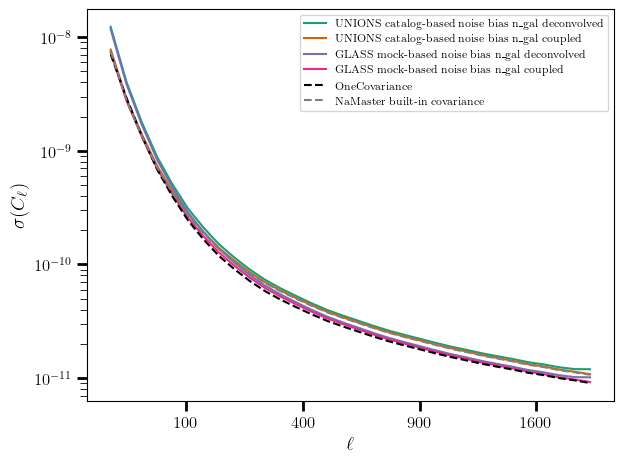

In [24]:
plt.figure()

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_unions_theo[:, 0, :, 0])),
    label='UNIONS catalog-based noise bias n_gal deconvolved'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_unions_theo_coupled[:, 0, :, 0])),
    label='UNIONS catalog-based noise bias n_gal coupled'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_glass_theo[:, 0, :, 0])),
    label='GLASS mock-based noise bias n_gal deconvolved'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(cov_glass_theo_coupled[:, 0, :, 0])),
    label='GLASS mock-based noise bias n_gal coupled'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(pseudo_cl_cov["COVAR_GAUSSIAN"].data)),
    color='black',
    linestyle='--',
    label='OneCovariance'
)

plt.plot(
    ell_eff,
    np.sqrt(np.diag(pseudo_cl_cov_namaster["COVAR_EE_EE"].data)),
    color='gray',
    label='NaMaster built-in covariance',
    linestyle='--'
)

plt.xscale('squareroot')
xticks = [100, 400, 900, 1600]
plt.xticks(xticks, xticks)
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\sigma(C_\ell)$")
plt.yscale('log')
plt.legend()

plt.savefig("./plots/errorbar_n_gal_map_decoupled_vs_coupled.png", dpi=300)
plt.show()

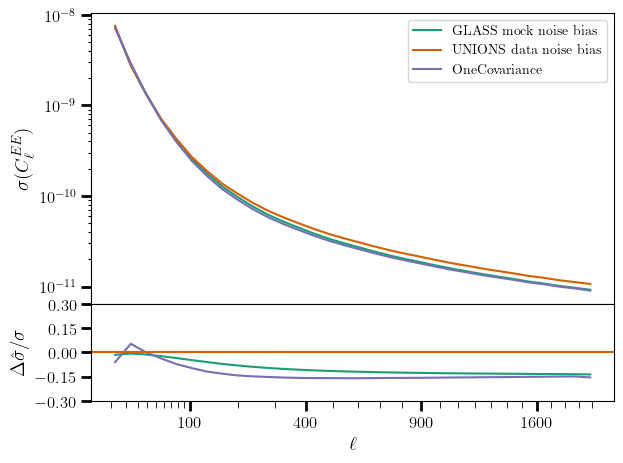

In [25]:
# Paperplot: effect of density variations on the covariance matrix

fig = plt.figure()

gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.0)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax1.plot(ell_eff, np.sqrt(np.diag(cov_glass_theo_coupled[:, 0, :, 0])), label="GLASS mock noise bias")
ax1.plot(ell_eff, np.sqrt(np.diag(pseudo_cl_cov_namaster["COVAR_EE_EE"].data)), label="UNIONS data noise bias")
ax1.plot(ell_eff, np.sqrt(np.diag(pseudo_cl_cov["COVAR_GAUSSIAN"].data)), label="OneCovariance", color='C2')

#Set ticks and scales for the x-axis
ax1.set_xscale('squareroot')
ax1.set_xticks(np.array([100, 400, 900, 1600]))
ax1.minorticks_on()
ax1.tick_params(axis='x', which='minor', length=2, width=0.8)
minor_ticks = [i*10 for i in range(1, 10)] + [i*100 for i in range(1, 21)]
ax1.set_xticks(minor_ticks, minor=True)

# Set ticks and scale for the y-axis
ax1.set_yscale('log')
ax1.set_yticks([1e-11, 1e-10, 1e-9, 1e-8])
ax1.tick_params(axis='y', which='minor', length=2, width=0.8)
minor_ticks = [i * 1e-11 for i in range(1, 10)] + [i * 1e-10 for i in range(1, 10)] + [i * 1e-9 for i in range(1, 10)]
ax1.set_yticks(minor_ticks, minor=True)

# Set labels and legend
ax1.set_ylabel(r"$\sigma(C_\ell^{EE})$")
ax1.legend(fontsize=10)

relative_error_glass = np.sqrt(np.diag(cov_glass_theo_coupled[:, 0, :, 0]))/np.sqrt(np.diag(pseudo_cl_cov_namaster["COVAR_EE_EE"].data))
relative_error_onecov = np.sqrt(np.diag(pseudo_cl_cov["COVAR_GAUSSIAN"].data))/np.sqrt(np.diag(pseudo_cl_cov_namaster["COVAR_EE_EE"].data))

ax2.plot(ell_eff, relative_error_glass - 1, label="GLASS mock noise bias")
ax2.plot(ell_eff, relative_error_onecov - 1, label="OneCovariance", color='C2')
ax2.axhline(0, color='C1', linestyle='-')

#Set ticks and scales for the y-axis
ax2.set_yticks([-0.3, -0.15, 0.0, 0.15, 0.3])
ax2.set_ylim(-0.3, 0.3)
ax2.set_ylabel(r"$ \Delta \hat{\sigma} / \sigma$")
ax2.set_xlabel(r"$\ell$")

plt.savefig("./plots/density_variation_effect_errorbar.png", dpi=300, bbox_inches='tight')
#Save pdf version
plt.savefig("./plots/density_variation_effect_errorbar.pdf", bbox_inches='tight')
plt.show()